In [55]:
# Imports
from kymotools.utils import fileutils
from numpy import genfromtxt

import csv
import matplotlib.pyplot as plt
import numpy as np
import os

In [56]:
# Parameters
filepath = '/Users/sc13967/Library/CloudStorage/OneDrive-UniversityofBristol/People/Gemma Fisher/2025-06-02 Foci colocalisation over time/Analysed/'
c_lim = [0,100]

In [57]:
dists = None

n_tracks_1 = 0
n_tracks_2 = 0

for filename in [name for name in os.listdir(filepath) if 'displacements.csv' in name]:
    curr_dists = genfromtxt(filepath+filename, delimiter=',')
    
    if np.isnan(curr_dists[0][0]):
        curr_dists = curr_dists[1::]
    if dists is None:
        dists = curr_dists
    else:
        dists = np.append(dists,curr_dists,0)
    
    n_tracks_1 = n_tracks_1 + len(np.unique(curr_dists[:,1]))
    n_tracks_2 = n_tracks_2 + len(np.unique(curr_dists[:,2]))


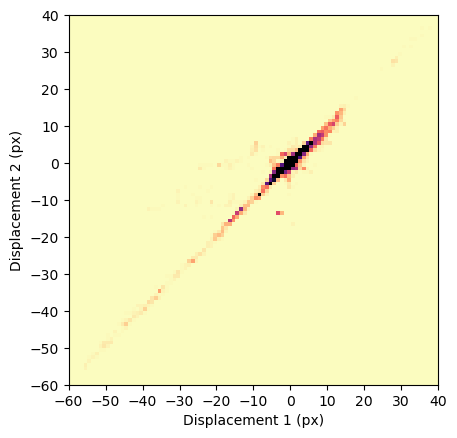

N = 13057
N tracks 1 (red) = 80
N tracks 2 (green) = 80


In [58]:
rootname = os.path.basename(os.path.splitext(filename)[0])

ax_min = np.floor(min(min(dists[:,7]),min(dists[:,8]))/10)*10
ax_max = np.ceil(max(max(dists[:,7]),max(dists[:,8]))/10)*10
n_bins = int(abs(ax_max)+abs(ax_min))
heatmap, xedges, yedges = np.histogram2d(dists[:,7], dists[:,8], range=[[ax_min,ax_max],[ax_min,ax_max]],bins=n_bins)
extent = [xedges[0], xedges[-1], yedges[0], yedges[-1]]
N = len(dists[:,8])

plt.imshow(heatmap.T, extent=extent, origin='lower')
plt.set_cmap('magma_r')
ax = plt.gca()
ax.set_xticks(xedges[0::10])
ax.set_yticks(yedges[0::10])
plt.clim(c_lim)
plt.xlabel('Displacement 1 (px)')
plt.ylabel('Displacement 2 (px)')
plt.savefig(filepath+rootname+"_displacement_hist_(N="+str(N)+")_plot.png")
plt.savefig(filepath+rootname+"_displacement_hist_(N="+str(N)+")_plot.svg")
plt.show()

print("N = %i"%N)
print("N tracks 1 (red) = %i"%n_tracks_1)
print("N tracks 2 (green) = %i"%n_tracks_2)
